# Pace Smoothing Notebook

This notebook is intentionally limited to the pace-smoothing experiment. The broader race analysis already lives in [colab/Half_Marathon_performance_analysis/Half_Marathon_performance_analysis__GPX_logs.ipynb](colab/Half_Marathon_performance_analysis/Half_Marathon_performance_analysis__GPX_logs.ipynb).

In [ ]:
!pip install gpxpy

import os

import gpxpy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from geopy.distance import geodesic

In [ ]:
# Use a redacted path placeholder so the source no longer exposes the local GPX location.
gpx_file_path = '<your-gpx-path>'

with open(gpx_file_path, 'r') as gpx_file:
    gpx = gpxpy.parse(gpx_file)

print(f"Loaded GPX data from {gpx_file_path} with {len(gpx.tracks)} tracks.")

Loaded GPX data from /content/drive/Othercomputers/My Mac/Desktop/Toronto_Half_Marathon_2026_.gpx with 1 tracks.


In [ ]:
# Flatten the GPX points into a dataframe
records = []
for track in gpx.tracks:
    for segment in track.segments:
        for point in segment.points:
            records.append({
                'latitude': point.latitude,
                'longitude': point.longitude,
                'elevation': point.elevation,
                'time': point.time,
            })

if not records:
    raise ValueError('No GPX points were found in the file.')

df = pd.DataFrame(records)
df['time'] = pd.to_datetime(df['time'], utc=True)
df = df.sort_values('time').reset_index(drop=True)

lat1 = df['latitude'].shift()
lon1 = df['longitude'].shift()
lat2 = df['latitude']
lon2 = df['longitude']

df['time_diff'] = df['time'].diff().dt.total_seconds().fillna(0.0)
df['distance_diff'] = [
    geodesic((lat1.iloc[i], lon1.iloc[i]), (lat2.iloc[i], lon2.iloc[i])).meters
    if pd.notna(lat1.iloc[i]) and pd.notna(lon1.iloc[i]) else 0.0
    for i in range(len(df))
]
df['cumulative_distance'] = df['distance_diff'].cumsum()
df['speed_mps'] = np.where(df['time_diff'] > 0, df['distance_diff'] / df['time_diff'], np.nan)
df['speed_kmh'] = df['speed_mps'] * 3.6
df['pace_min_per_km'] = np.where(df['speed_kmh'] > 0, 60 / df['speed_kmh'], np.nan)

df['kilometer_segment'] = (df['cumulative_distance'] / 1000).astype(int)
df['smoothed_pace_min_per_km'] = df['pace_min_per_km']

# Smooth pace values post-race for the 18 km and 19 km rows.
df = df.set_index('time')
for segment in [18, 19]:
    mask = df['kilometer_segment'] == segment
    if mask.any():
        df.loc[mask, 'smoothed_pace_min_per_km'] = df.loc[mask, 'pace_min_per_km'].rolling(window='5min', center=True, min_periods=1).median()

df = df[df['cumulative_distance'] <= 22000].reset_index(drop=True)

print(df[['time', 'cumulative_distance', 'speed_kmh', 'pace_min_per_km', 'smoothed_pace_min_per_km']].head())
print(f"Prepared {len(df)} rows for pace smoothing analysis.")

    latitude  longitude  elevation  time_diff  distance_diff  \
0  43.767106 -79.412424      176.8        0.0       0.000000   
1  43.767068 -79.412409      176.8        2.0       4.393734   
2  43.767041 -79.412401      176.7        1.0       3.070222   
3  43.767007 -79.412386      176.7        1.0       3.967868   
4  43.766973 -79.412371      176.7        1.0       3.967868   

   cumulative_distance  speed_mps  speed_kmh  kilometer_segment  \
0             0.000000        NaN        NaN                  0   
1             4.393734   2.196867   7.908721                  0   
2             7.463956   3.070222  11.052800                  0   
3            11.431824   3.967868  14.284325                  0   
4            15.399692   3.967868  14.284326                  0   

   smoothed_speed_kmh  smoothed_elevation  elevation_change  
0                 NaN               176.8               NaN  
1            7.908721               176.8               0.0  
2           11.052800     

In [ ]:
# Aggregate by kilometer segment
aggregated_data = df.groupby('kilometer_segment').agg(
    avg_pace_min_per_km=('smoothed_pace_min_per_km', 'mean'),
    raw_avg_pace_min_per_km=('pace_min_per_km', 'mean'),
    total_time_seconds=('time_diff', 'sum')
).reset_index()

aggregated_data['total_time_minutes'] = aggregated_data['total_time_seconds'] / 60
aggregated_data['smoothed_avg_pace_min_per_km'] = aggregated_data['avg_pace_min_per_km']


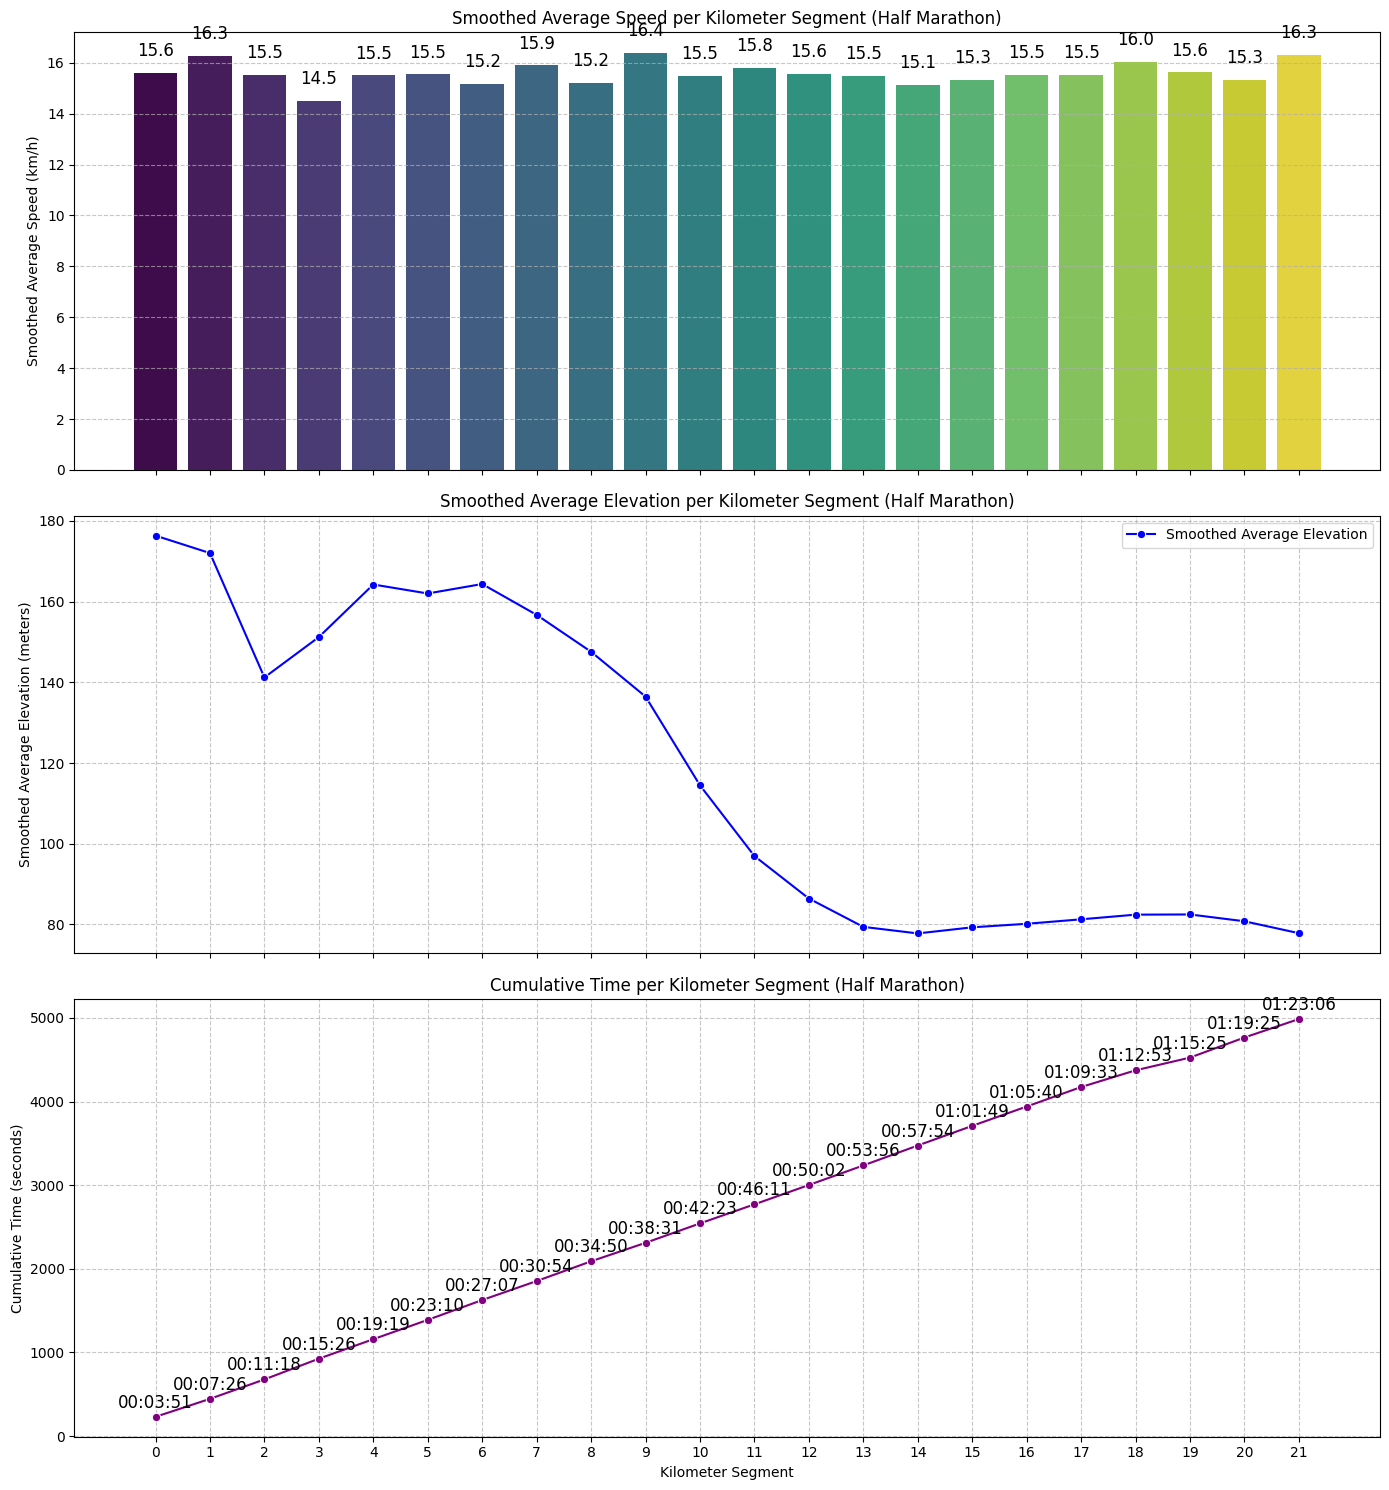

In [ ]:
aggregated_data['cumulative_time_seconds'] = aggregated_data['total_time_seconds'].cumsum()

plt.figure(figsize=(14, 6))
ax = plt.gca()
sns.barplot(
    x=aggregated_data['kilometer_segment'],
    y='smoothed_avg_pace_min_per_km',
    data=aggregated_data,
    ax=ax,
    legend=False,
)
ax.set_title('Smoothed average pace per kilometer segment')
ax.set_xlabel('Kilometer segment')
ax.set_ylabel('Smoothed average pace (min/km)')
ax.grid(axis='y', linestyle='--', alpha=0.7)

for _, row in aggregated_data.iterrows():
    ax.text(
        row['kilometer_segment'],
        row['smoothed_avg_pace_min_per_km'] + 0.05,
        f"{row['smoothed_avg_pace_min_per_km']:.2f}",
        ha='center',
        va='bottom',
        fontsize=10,
    )

plt.tight_layout()
plt.show()